# Step 5 - Loss Ratio & Profitability Analysis

Notebook ini fokus menjawab: **segmen mana yang paling menguntungkan dan paling merugikan?**

Framework yang dipakai:
- Gross Loss Ratio = Gross Incurred Claim / Gross Written Premium
- Net Loss Ratio = Net Incurred Claim / Net Premium
- Ranking per segmen dengan filter kredibilitas
- Perbandingan gross vs net position setelah reasuransi
- Analisis large claim sebagai sensitivity analysis
- Analisis tren loss ratio per underwriting year
- Tambahan underwriting result sebagai indikator profitabilitas sederhana


## Ringkasan konsep bisnis

Dari diskusi bisnis sebelumnya:
- `GWP_IDR` = gross written premium, yaitu premi kotor yang dibayar nasabah.
- `RWP_IDR` = premi yang diberikan ke reasuransi.
- `GWC_IDR` = komisi yang dibayar AXA ke agen atau broker.
- `RWC_IDR` = komisi dari reasuransi.
- `GRS_ST_IDR` = klaim kotor yang sudah dibayar.
- `RI_ST_IDR` = bagian settled claim yang ditanggung reasuransi.
- `GRS_OS_IDR` = outstanding claim gross, yaitu cadangan klaim yang belum selesai.
- `RI_OS_IDR` = bagian outstanding claim yang diperkirakan ditanggung reasuransi.

Formula utama:
- Gross Claim = `GRS_ST_IDR + GRS_OS_IDR`
- Reinsurance Recovery = `RI_ST_IDR + RI_OS_IDR`
- Net Claim = `Gross Claim - Reinsurance Recovery`
- Net Premium = `GWP_IDR - RWP_IDR`
- Net Commission = `GWC_IDR - RWC_IDR`
- Gross Underwriting Result = `GWP_IDR - Gross Claim - GWC_IDR`
- Net Underwriting Result = `Net Premium - Net Claim - Net Commission`

Catatan penting interpretasi reasuransi:
- `Net Loss Ratio` bisa lebih tinggi dari `Gross Loss Ratio` karena **net premium** lebih kecil dari gross premium.
- Karena itu, efektivitas reasuransi tidak aman dinilai hanya dari selisih `Gross LR - Net LR`.
- Untuk melihat bantuan reasuransi, kita tampilkan juga **reinsurance recovery** dan **claim relief ratio**.


In [3]:
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='viridis')

# Config yang mudah diubah di Colab
USE_COLAB_UPLOAD = True
LOCAL_FILE_PATH = '/content/Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1).xlsx'

SEGMENT_COLS = ['COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME']
FOCUS_SEGMENT = 'COB'
TOP_N = 10

# Filter kredibilitas supaya ranking tidak didominasi segmen kecil/outlier.
MIN_GWP_BY_SEGMENT = 1_000_000_000
MIN_NET_PREMIUM_BY_SEGMENT = 1_000_000_000
MIN_POLICY_COUNT = 50
MIN_CLAIM_POLICY_COUNT = 5

# Untuk product, pakai guardrail lebih ketat karena paling rawan outlier.
PRODUCT_MIN_POLICY_COUNT = 200
PRODUCT_MIN_CLAIM_POLICY_COUNT = 10
PRODUCT_MIN_NET_PREMIUM = 5_000_000_000
PRODUCT_MAX_NET_LR_FOR_MAIN_RANKING = 500

# Large claim didefinisikan dari gross claim di level policy.
LARGE_CLAIM_QUANTILE = 0.95

if USE_COLAB_UPLOAD:
    from google.colab import files
    uploaded = files.upload()
    file_path = next(iter(uploaded.keys()))
else:
    file_path = LOCAL_FILE_PATH

print(f'File yang dipakai: {file_path}')


Saving Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1).xlsx to Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1) (1).xlsx
File yang dipakai: Study Case for Univ Airlangga 2026 _Actuarial AXA (Sent 2026.05.26) (1) (1).xlsx


In [4]:
premium_cols = [
    'COB', 'BRANCH_', 'CHANNEL_', 'PRODUCT_NAME', 'POLICY_NO',
    'DT_INC', 'DT_END', 'GWP_IDR', 'RWP_IDR', 'GWC_IDR', 'RWC_IDR', 'SUM_INSURED'
]
claim_cols = [
    'COB', 'BRANCH_', 'CHANNEL_', 'POLICY_NO', 'CLM_REF', 'DT_CLM',
    'GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR'
]

premium = pd.read_excel(file_path, sheet_name='Raw Premium', usecols=premium_cols)
claim = pd.read_excel(file_path, sheet_name='Raw Claim', usecols=claim_cols)

for col in ['DT_INC', 'DT_END']:
    premium[col] = pd.to_datetime(premium[col], errors='coerce')
for col in ['DT_CLM']:
    claim[col] = pd.to_datetime(claim[col], errors='coerce')

for col in ['GWP_IDR', 'RWP_IDR', 'GWC_IDR', 'RWC_IDR', 'SUM_INSURED']:
    premium[col] = pd.to_numeric(premium[col], errors='coerce').fillna(0)
for col in ['GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR']:
    claim[col] = pd.to_numeric(claim[col], errors='coerce').fillna(0)

print('Premium shape :', premium.shape)
print('Claim shape   :', claim.shape)
display(premium.head())
display(claim.head())


Premium shape : (390124, 12)
Claim shape   : (20087, 10)


,COB,BRANCH_,CHANNEL_,PRODUCT_NAME,POLICY_NO,DT_INC,DT_END,GWP_IDR,RWP_IDR,GWC_IDR,RWC_IDR,SUM_INSURED
0,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001100803012100001,2021-01-01,2021-07-01,"37,514.11",0.00,0.00,0.00,"42,500,000.00"
1,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001100803012100003,2021-01-01,2021-07-01,"443,738.96",0.00,0.00,0.00,"502,715,000.00"
2,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001020803022100007,2021-01-01,2021-08-01,"452,315.07",0.00,"45,231.51",0.00,"437,500,000.00"
3,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001020803122000006,2021-01-01,2021-08-01,"96,924.66",0.00,"9,692.47",0.00,"93,750,000.00"
4,COB 1,BRANCH J,CHANNEL D,PRODUCT0803,YY_00001020803122000007,2021-01-01,2021-08-01,"2,756,090.75",0.00,"275,609.08",0.00,"238,750,000.00"


,COB,BRANCH_,CHANNEL_,POLICY_NO,CLM_REF,DT_CLM,GRS_ST_IDR,RI_ST_IDR,GRS_OS_IDR,RI_OS_IDR
0,COB 1,BRANCH J,CHANNEL A,YY_00001110802022100001,XX_-110802042200001,2022-03-31,"9,000,000.00",0.00,0.00,0.00
1,COB 1,BRANCH J,CHANNEL A,YY_00001110802022100001,XX_-110802072200001,2022-07-05,"41,198,727.60",0.00,0.00,0.00
2,COB 1,BRANCH D,CHANNEL E,YY_00001050808072100002,XX_-050808122100013,2021-12-03,"517,752,648.00","457,057,854.92",0.00,0.00
3,COB 1,BRANCH D,CHANNEL E,YY_00001050808022100001,XX_-050808122100001,2021-07-19,"36,371,730.60","34,895,511.95",0.00,0.00
4,COB 1,BRANCH D,CHANNEL E,YY_00001050808022100001,XX_-050808012200001,2021-07-20,"1,188,597,879.90","1,140,356,283.24",0.00,0.00


In [5]:
# Policy-level summary untuk menghindari double count saat join.
premium_policy = (
    premium.sort_values(['POLICY_NO', 'DT_INC'])
    .groupby('POLICY_NO', as_index=False)
    .agg({
        'COB': 'first',
        'BRANCH_': 'first',
        'CHANNEL_': 'first',
        'PRODUCT_NAME': 'first',
        'DT_INC': 'min',
        'DT_END': 'max',
        'GWP_IDR': 'sum',
        'RWP_IDR': 'sum',
        'GWC_IDR': 'sum',
        'RWC_IDR': 'sum',
        'SUM_INSURED': 'max'
    })
)

claim_policy = (
    claim.groupby('POLICY_NO', as_index=False)
    .agg({
        'CLM_REF': 'nunique',
        'DT_CLM': 'min',
        'GRS_ST_IDR': 'sum',
        'RI_ST_IDR': 'sum',
        'GRS_OS_IDR': 'sum',
        'RI_OS_IDR': 'sum'
    })
    .rename(columns={'CLM_REF': 'claim_count'})
)

claim_range_check = claim.merge(
    premium_policy[['POLICY_NO', 'DT_INC', 'DT_END']],
    on='POLICY_NO', how='left'
)

df = premium_policy.merge(claim_policy, on='POLICY_NO', how='left')
fill_cols = ['claim_count', 'GRS_ST_IDR', 'RI_ST_IDR', 'GRS_OS_IDR', 'RI_OS_IDR']
df[fill_cols] = df[fill_cols].fillna(0)

df['uw_year'] = df['DT_INC'].dt.year
df['net_premium'] = df['GWP_IDR'] - df['RWP_IDR']
df['gross_claim'] = df['GRS_ST_IDR'] + df['GRS_OS_IDR']
df['reinsurance_recovery'] = df['RI_ST_IDR'] + df['RI_OS_IDR']
df['net_claim'] = df['gross_claim'] - df['reinsurance_recovery']
df['net_commission'] = df['GWC_IDR'] - df['RWC_IDR']
df['gross_underwriting_result'] = df['GWP_IDR'] - df['gross_claim'] - df['GWC_IDR']
df['net_underwriting_result'] = df['net_premium'] - df['net_claim'] - df['net_commission']
df['has_claim'] = df['gross_claim'] > 0

positive_claims = df.loc[df['gross_claim'] > 0, 'gross_claim']
large_claim_threshold = positive_claims.quantile(LARGE_CLAIM_QUANTILE)
df['is_large_claim'] = df['gross_claim'] >= large_claim_threshold

qa_summary = pd.DataFrame({
    'metric': [
        'policy_count', 'claim_policy_count', 'gwp_total', 'net_premium_total',
        'gross_claim_total', 'reinsurance_recovery_total', 'net_claim_total',
        'gross_underwriting_result_total', 'net_underwriting_result_total', 'large_claim_threshold'
    ],
    'value': [
        len(df),
        int(df['has_claim'].sum()),
        df['GWP_IDR'].sum(),
        df['net_premium'].sum(),
        df['gross_claim'].sum(),
        df['reinsurance_recovery'].sum(),
        df['net_claim'].sum(),
        df['gross_underwriting_result'].sum(),
        df['net_underwriting_result'].sum(),
        large_claim_threshold
    ]
})

data_quality = pd.DataFrame({
    'check': [
        'duplicate rows in premium by policy',
        'claim rows before inception',
        'claim rows after policy end',
        'non-positive net premium policy count'
    ],
    'count': [
        int((premium.groupby('POLICY_NO').size() > 1).sum()),
        int(((claim_range_check['DT_CLM'].notna()) & (claim_range_check['DT_CLM'] < claim_range_check['DT_INC'])).sum()),
        int(((claim_range_check['DT_CLM'].notna()) & (claim_range_check['DT_CLM'] > claim_range_check['DT_END'])).sum()),
        int((df['net_premium'] <= 0).sum())
    ]
})

display(qa_summary)
display(data_quality)
display(df.head())


,metric,value
0,policy_count,"156,301.00"
1,claim_policy_count,"8,585.00"
2,gwp_total,"2,510,719,474,050.44"
3,net_premium_total,"1,964,121,257,568.66"
4,gross_claim_total,"1,238,881,565,028.47"
5,reinsurance_recovery_total,"89,128,475,259.40"
6,net_claim_total,"1,149,753,089,769.06"
7,gross_underwriting_result_total,"712,039,594,336.15"
8,net_underwriting_result_total,"358,745,337,626.98"
9,large_claim_threshold,"153,078,629.76"


,check,count
0,duplicate rows in premium by policy,1573
1,claim rows before inception,0
2,claim rows after policy end,0
3,non-positive net premium policy count,164


,POLICY_NO,COB,BRANCH_,CHANNEL_,PRODUCT_NAME,DT_INC,DT_END,GWP_IDR,RWP_IDR,GWC_IDR,RWC_IDR,SUM_INSURED,claim_count,DT_CLM,GRS_ST_IDR,RI_ST_IDR,GRS_OS_IDR,RI_OS_IDR,uw_year,net_premium,gross_claim,reinsurance_recovery,net_claim,net_commission,gross_underwriting_result,net_underwriting_result,has_claim,is_large_claim
0,YY_000000AGI-1-00258366,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-03-01,2023-04-01,"72,482,500.00","7,686.36","21,744,750.00","1,867.57","450,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"72,474,813.64",0.00,0.00,0.00,"21,742,882.43","50,737,750.00","50,731,931.22",False,False
1,YY_000000AGI-1-00260948,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-01-07,2023-02-06,"30,607,500.00","3,267.45","9,182,250.00",796.59,"900,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"30,604,232.55",0.00,0.00,0.00,"9,181,453.41","21,425,250.00","21,422,779.14",False,False
2,YY_000000AGI-1-00261491,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-08-18,2023-09-18,"33,390,000.00","3,267.45","10,017,000.00",796.59,"900,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"33,386,732.55",0.00,0.00,0.00,"10,016,203.41","23,373,000.00","23,370,529.14",False,False
3,YY_000000AGI-1-00262632,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-02-03,2023-03-03,"16,843,750.00","1,763.67","5,053,125.00",431.48,"450,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"16,841,986.33",0.00,0.00,0.00,"5,052,693.52","11,790,625.00","11,789,292.81",False,False
4,YY_000000AGI-1-00262638,COB 2,BRANCH K,CHANNEL B,PRODUCT13AG,2023-03-03,2023-04-03,"38,707,500.00","4,001.02","11,612,250.00",978.85,"1,350,000,000.00",0.00,NaT,0.00,0.00,0.00,0.00,2023,"38,703,498.98",0.00,0.00,0.00,"11,611,271.15","27,095,250.00","27,092,227.84",False,False


In [6]:
def safe_ratio(numerator, denominator):
    return np.where(denominator != 0, numerator / denominator, np.nan)


def segment_filter(summary, group_col):
    base_filter = (
        (summary['gwp'] >= MIN_GWP_BY_SEGMENT) &
        (summary['net_premium'] >= MIN_NET_PREMIUM_BY_SEGMENT) &
        (summary['policy_count'] >= MIN_POLICY_COUNT) &
        (summary['claim_policy_count'] >= MIN_CLAIM_POLICY_COUNT)
    )

    if group_col == 'PRODUCT_NAME':
        base_filter = (
            (summary['gwp'] >= MIN_GWP_BY_SEGMENT) &
            (summary['net_premium'] >= PRODUCT_MIN_NET_PREMIUM) &
            (summary['policy_count'] >= PRODUCT_MIN_POLICY_COUNT) &
            (summary['claim_policy_count'] >= PRODUCT_MIN_CLAIM_POLICY_COUNT) &
            (summary['net_loss_ratio_pct'] <= PRODUCT_MAX_NET_LR_FOR_MAIN_RANKING)
        )

    return summary[base_filter].copy()


def summarize_segment(data, group_col):
    summary = (
        data.groupby(group_col, dropna=False)
        .agg(
            policy_count=('POLICY_NO', 'nunique'),
            claim_policy_count=('has_claim', 'sum'),
            large_claim_policy_count=('is_large_claim', 'sum'),
            gwp=('GWP_IDR', 'sum'),
            rwp=('RWP_IDR', 'sum'),
            net_premium=('net_premium', 'sum'),
            gross_claim=('gross_claim', 'sum'),
            reinsurance_recovery=('reinsurance_recovery', 'sum'),
            net_claim=('net_claim', 'sum'),
            gross_commission=('GWC_IDR', 'sum'),
            reinsurance_commission=('RWC_IDR', 'sum'),
            net_commission=('net_commission', 'sum'),
            gross_underwriting_result=('gross_underwriting_result', 'sum'),
            net_underwriting_result=('net_underwriting_result', 'sum')
        )
        .reset_index()
    )

    summary['gross_loss_ratio_pct'] = 100 * safe_ratio(summary['gross_claim'], summary['gwp'])
    summary['net_loss_ratio_pct'] = 100 * safe_ratio(summary['net_claim'], summary['net_premium'])
    summary['premium_ceded_pct'] = 100 * safe_ratio(summary['rwp'], summary['gwp'])
    summary['claim_relief_pct_of_gross_claim'] = 100 * safe_ratio(summary['reinsurance_recovery'], summary['gross_claim'])
    summary['net_vs_gross_lr_gap_pct_point'] = summary['net_loss_ratio_pct'] - summary['gross_loss_ratio_pct']
    summary['gross_underwriting_margin_pct'] = 100 * safe_ratio(summary['gross_underwriting_result'], summary['gwp'])
    summary['net_underwriting_margin_pct'] = 100 * safe_ratio(summary['net_underwriting_result'], summary['net_premium'])
    summary['profitability_flag'] = np.where(summary['net_loss_ratio_pct'] > 100, 'Loss-making', 'Profitable/acceptable')

    summary = segment_filter(summary, group_col)
    return summary.sort_values(['net_loss_ratio_pct', 'net_underwriting_result'], ascending=[True, False]).reset_index(drop=True)


def overall_metrics(data, scenario_name):
    total_gwp = data['GWP_IDR'].sum()
    total_rwp = data['RWP_IDR'].sum()
    total_net_premium = data['net_premium'].sum()
    total_gross_claim = data['gross_claim'].sum()
    total_recovery = data['reinsurance_recovery'].sum()
    total_net_claim = data['net_claim'].sum()
    total_gross_uw = data['gross_underwriting_result'].sum()
    total_net_uw = data['net_underwriting_result'].sum()

    return pd.DataFrame({
        'scenario': [scenario_name],
        'policy_count': [data['POLICY_NO'].nunique()],
        'claim_policy_count': [int(data['has_claim'].sum())],
        'gwp': [total_gwp],
        'rwp': [total_rwp],
        'net_premium': [total_net_premium],
        'gross_claim': [total_gross_claim],
        'reinsurance_recovery': [total_recovery],
        'net_claim': [total_net_claim],
        'gross_loss_ratio_pct': [100 * total_gross_claim / total_gwp],
        'net_loss_ratio_pct': [100 * total_net_claim / total_net_premium],
        'premium_ceded_pct': [100 * total_rwp / total_gwp],
        'claim_relief_pct_of_gross_claim': [100 * total_recovery / total_gross_claim if total_gross_claim != 0 else np.nan],
        'gross_underwriting_result': [total_gross_uw],
        'net_underwriting_result': [total_net_uw]
    })


segment_summaries = {col: summarize_segment(df, col) for col in SEGMENT_COLS}

# Outlier products dipisahkan dari ranking utama.
product_all = (
    df.groupby('PRODUCT_NAME', dropna=False)
    .agg(
        policy_count=('POLICY_NO', 'nunique'),
        claim_policy_count=('has_claim', 'sum'),
        net_premium=('net_premium', 'sum'),
        net_claim=('net_claim', 'sum')
    )
    .reset_index()
)
product_all['net_loss_ratio_pct'] = 100 * safe_ratio(product_all['net_claim'], product_all['net_premium'])
product_outliers = product_all[
    (product_all['policy_count'] >= PRODUCT_MIN_POLICY_COUNT) &
    (product_all['claim_policy_count'] >= PRODUCT_MIN_CLAIM_POLICY_COUNT) &
    (product_all['net_premium'] >= PRODUCT_MIN_NET_PREMIUM) &
    (product_all['net_loss_ratio_pct'] > PRODUCT_MAX_NET_LR_FOR_MAIN_RANKING)
].sort_values('net_loss_ratio_pct', ascending=False)

for col, summary in segment_summaries.items():
    print(f'=== Best segments by {col} ===')
    display(summary.head(TOP_N))
    print(f'=== Worst segments by {col} ===')
    display(summary.sort_values(['net_loss_ratio_pct', 'net_underwriting_result'], ascending=[False, True]).head(TOP_N))

print('=== Product outliers excluded from main ranking ===')
display(product_outliers.head(TOP_N))


=== Best segments by COB ===


,COB,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_claim,reinsurance_recovery,net_claim,gross_commission,reinsurance_commission,net_commission,gross_underwriting_result,net_underwriting_result,gross_loss_ratio_pct,net_loss_ratio_pct,premium_ceded_pct,claim_relief_pct_of_gross_claim,net_vs_gross_lr_gap_pct_point,gross_underwriting_margin_pct,net_underwriting_margin_pct,profitability_flag
0,COB 3,835,36,2,"57,467,926,067.73","42,919,774,251.80","14,548,151,815.93","1,280,414,194.54","402,457,725.36","877,956,469.18","2,909,283,224.11","5,599,910,745.57","-2,690,627,521.46","53,278,228,649.08","16,360,822,868.21",2.23,6.03,74.68,31.43,3.81,92.71,112.46,Profitable/acceptable
1,COB 10,52085,330,6,"64,892,499,838.20",0.00,"64,892,499,838.20","5,870,562,105.60",0.00,"5,870,562,105.60","10,480,316,187.72",0.00,"10,480,316,187.72","48,541,621,544.89","48,541,621,544.89",9.05,9.05,0.00,0.00,0.00,74.80,74.80,Profitable/acceptable
2,COB 8,2382,50,4,"251,534,301,544.45","44,825,850.00","251,489,475,694.45","37,829,764,117.97",0.00,"37,829,764,117.97","109,384,567,225.76","13,696,787.50","109,370,870,438.26","104,319,970,200.72","104,288,841,138.22",15.04,15.04,0.02,0.00,0.00,41.47,41.47,Profitable/acceptable
3,COB 9,46754,704,110,"762,410,875,051.46","295,418,868,386.00","466,992,006,665.47","130,691,192,885.20","42,768,357,218.66","87,922,835,666.55","75,319,729,105.86","67,118,908,209.68","8,200,820,896.18","556,399,953,060.40","370,868,350,102.74",17.14,18.83,38.75,32.72,1.69,72.98,79.42,Profitable/acceptable
4,COB 1,4983,97,24,"119,618,908,447.19","69,935,087,727.82","49,683,820,719.38","26,166,689,951.10","13,382,773,780.97","12,783,916,170.13","17,756,994,451.54","11,770,029,176.60","5,986,965,274.94","75,695,224,044.55","30,912,939,274.31",21.88,25.73,58.46,51.14,3.86,63.28,62.22,Profitable/acceptable
5,COB 5,909,62,35,"151,000,896,289.24","76,311,390,292.49","74,689,505,996.75","58,025,722,142.83","20,977,902,285.80","37,047,819,857.04","16,776,988,662.05","9,450,911,725.05","7,326,076,937.00","76,198,185,484.36","30,315,609,202.71",38.43,49.60,50.54,36.15,11.18,50.46,40.59,Profitable/acceptable
6,COB 7,41763,6986,109,"342,980,363,837.09","283,482,868.75","342,696,880,968.34","298,159,145,749.09","29,689,740.00","298,129,456,009.09","56,776,920,708.06","87,248,247.58","56,689,672,460.48","-11,955,702,620.06","-12,122,247,501.23",86.93,87.00,0.08,0.01,0.06,-3.49,-3.54,Profitable/acceptable
7,COB 6,4876,109,12,"420,660,523,861.31","5,476,913,501.38","415,183,610,359.93","384,069,692,453.56","431,091,611.56","383,638,600,841.99","182,890,459,304.63","1,435,816,882.96","181,454,642,421.67","-146,299,627,896.87","-149,909,632,903.73",91.30,92.40,1.30,0.11,1.10,-34.78,-36.11,Profitable/acceptable
8,COB 4,1693,208,126,"319,207,543,543.36","56,207,821,801.20","262,999,721,742.16","291,354,181,428.57","11,136,202,897.05","280,217,978,531.52","83,153,822,823.92","8,698,949,991.14","74,454,872,832.78","-55,300,460,709.13","-91,673,129,622.13",91.27,106.55,17.61,3.82,15.27,-17.32,-34.86,Loss-making


=== Worst segments by COB ===


,COB,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_claim,reinsurance_recovery,net_claim,gross_commission,reinsurance_commission,net_commission,gross_underwriting_result,net_underwriting_result,gross_loss_ratio_pct,net_loss_ratio_pct,premium_ceded_pct,claim_relief_pct_of_gross_claim,net_vs_gross_lr_gap_pct_point,gross_underwriting_margin_pct,net_underwriting_margin_pct,profitability_flag
8,COB 4,1693,208,126,"319,207,543,543.36","56,207,821,801.20","262,999,721,742.16","291,354,181,428.57","11,136,202,897.05","280,217,978,531.52","83,153,822,823.92","8,698,949,991.14","74,454,872,832.78","-55,300,460,709.13","-91,673,129,622.13",91.27,106.55,17.61,3.82,15.27,-17.32,-34.86,Loss-making
7,COB 6,4876,109,12,"420,660,523,861.31","5,476,913,501.38","415,183,610,359.93","384,069,692,453.56","431,091,611.56","383,638,600,841.99","182,890,459,304.63","1,435,816,882.96","181,454,642,421.67","-146,299,627,896.87","-149,909,632,903.73",91.30,92.40,1.30,0.11,1.10,-34.78,-36.11,Profitable/acceptable
6,COB 7,41763,6986,109,"342,980,363,837.09","283,482,868.75","342,696,880,968.34","298,159,145,749.09","29,689,740.00","298,129,456,009.09","56,776,920,708.06","87,248,247.58","56,689,672,460.48","-11,955,702,620.06","-12,122,247,501.23",86.93,87.00,0.08,0.01,0.06,-3.49,-3.54,Profitable/acceptable
5,COB 5,909,62,35,"151,000,896,289.24","76,311,390,292.49","74,689,505,996.75","58,025,722,142.83","20,977,902,285.80","37,047,819,857.04","16,776,988,662.05","9,450,911,725.05","7,326,076,937.00","76,198,185,484.36","30,315,609,202.71",38.43,49.60,50.54,36.15,11.18,50.46,40.59,Profitable/acceptable
4,COB 1,4983,97,24,"119,618,908,447.19","69,935,087,727.82","49,683,820,719.38","26,166,689,951.10","13,382,773,780.97","12,783,916,170.13","17,756,994,451.54","11,770,029,176.60","5,986,965,274.94","75,695,224,044.55","30,912,939,274.31",21.88,25.73,58.46,51.14,3.86,63.28,62.22,Profitable/acceptable
3,COB 9,46754,704,110,"762,410,875,051.46","295,418,868,386.00","466,992,006,665.47","130,691,192,885.20","42,768,357,218.66","87,922,835,666.55","75,319,729,105.86","67,118,908,209.68","8,200,820,896.18","556,399,953,060.40","370,868,350,102.74",17.14,18.83,38.75,32.72,1.69,72.98,79.42,Profitable/acceptable
2,COB 8,2382,50,4,"251,534,301,544.45","44,825,850.00","251,489,475,694.45","37,829,764,117.97",0.00,"37,829,764,117.97","109,384,567,225.76","13,696,787.50","109,370,870,438.26","104,319,970,200.72","104,288,841,138.22",15.04,15.04,0.02,0.00,0.00,41.47,41.47,Profitable/acceptable
1,COB 10,52085,330,6,"64,892,499,838.20",0.00,"64,892,499,838.20","5,870,562,105.60",0.00,"5,870,562,105.60","10,480,316,187.72",0.00,"10,480,316,187.72","48,541,621,544.89","48,541,621,544.89",9.05,9.05,0.00,0.00,0.00,74.80,74.80,Profitable/acceptable
0,COB 3,835,36,2,"57,467,926,067.73","42,919,774,251.80","14,548,151,815.93","1,280,414,194.54","402,457,725.36","877,956,469.18","2,909,283,224.11","5,599,910,745.57","-2,690,627,521.46","53,278,228,649.08","16,360,822,868.21",2.23,6.03,74.68,31.43,3.81,92.71,112.46,Profitable/acceptable


=== Best segments by BRANCH_ ===


...

,PRODUCT_NAME,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_claim,reinsurance_recovery,net_claim,gross_commission,reinsurance_commission,net_commission,gross_underwriting_result,net_underwriting_result,gross_loss_ratio_pct,net_loss_ratio_pct,premium_ceded_pct,claim_relief_pct_of_gross_claim,net_vs_gross_lr_gap_pct_point,gross_underwriting_margin_pct,net_underwriting_margin_pct,profitability_flag
0,PRODUCT1006,1593,19,0,"5,500,358,859.60","44,825,850.00","5,455,533,009.60","142,816,072.50",0.00,"142,816,072.50","587,708,974.79","13,696,787.50","574,012,187.29","4,769,833,812.31","4,738,704,749.81",2.60,2.62,0.81,0.00,0.02,86.72,86.86,Profitable/acceptable
1,PRODUCT0114,681,20,4,"46,120,529,512.93","22,979,671,607.03","23,140,857,905.90","2,721,841,903.03","1,453,303,114.83","1,268,538,788.20","2,293,285,326.27","6,183,795,140.05","-3,890,509,813.77","41,105,402,283.63","25,762,828,931.47",5.90,5.48,49.83,53.39,-0.42,89.13,111.33,Profitable/acceptable
2,PRODUCT0122,5327,44,7,"115,770,388,948.01","64,521,814,325.31","51,248,574,622.70","4,115,714,274.79","1,279,515,022.66","2,836,199,252.14","8,202,637,457.63","17,617,150,269.05","-9,414,512,811.42","103,452,037,215.59","57,826,888,181.99",3.56,5.53,55.73,31.09,1.98,89.36,112.84,Profitable/acceptable
3,PRODUCT1021,49405,321,6,"58,072,668,000.78",0.00,"58,072,668,000.78","5,662,231,705.27",0.00,"5,662,231,705.27","9,874,371,275.45",0.00,"9,874,371,275.45","42,536,065,020.06","42,536,065,020.06",9.75,9.75,0.00,0.00,0.00,73.25,73.25,Profitable/acceptable
4,PRODUCT0309,915,15,6,"25,004,088,524.06","12,110,422,331.96","12,893,666,192.10","3,322,624,085.43","1,913,015,080.91","1,409,609,004.52","3,709,428,904.89","1,720,457,419.97","1,988,971,484.92","17,972,035,533.74","9,495,085,702.66",13.29,10.93,48.43,57.58,-2.36,71.88,73.64,Profitable/acceptable
5,PRODUCT0901,425,27,1,"25,541,897,498.87","20,368,185,477.11","5,173,712,021.76","804,018,498.79","70,363,171.41","733,655,327.37","1,223,174,194.14","2,467,066,408.87","-1,243,892,214.73","23,514,704,805.94","5,683,948,909.12",3.15,14.18,79.74,8.75,11.03,92.06,109.86,Profitable/acceptable
6,PRODUCT0101,9807,11,7,"53,257,328,931.24","8,381,355,542.60","44,875,973,388.65","12,830,403,892.96","2,438,022,035.08","10,392,381,857.88","7,489,717,669.04","2,266,654,250.21","5,223,063,418.82","32,937,207,369.25","29,260,528,111.95",24.09,23.16,15.74,19.00,-0.93,61.85,65.20,Profitable/acceptable
7,PRODUCT0134,1737,27,4,"18,786,904,471.65","5,495,420,900.14","13,291,483,571.51","6,310,543,344.03","1,374,144,308.56","4,936,399,035.47","1,534,717,358.04","1,398,570,491.96","136,146,866.08","10,941,643,769.58","8,218,937,669.96",33.59,37.14,29.25,21.78,3.55,58.24,61.84,Profitable/acceptable
8,PRODUCT0201,3178,744,29,"57,383,262,167.93","125,650,312.50","57,257,611,855.43","24,198,529,609.40","29,689,740.00","24,168,839,869.40","6,970,144,589.67","39,345,023.44","6,930,799,566.23","26,214,587,968.86","26,157,972,419.79",42.17,42.21,0.22,0.12,0.04,45.68,45.68,Profitable/acceptable
9,PRODUCT0110,1545,135,27,"132,827,204,958.30","93,842,169,194.05","38,985,035,764.26","28,968,032,741.31","12,200,800,736.32","16,767,232,004.99","11,342,100,621.64","14,227,634,772.17","-2,885,534,150.53","92,517,071,595.35","25,103,337,909.79",21.81,43.01,70.65,42.12,21.20,69.65,64.39,Profitable/acceptable


=== Worst segments by PRODUCT_NAME ===


,PRODUCT_NAME,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_claim,reinsurance_recovery,net_claim,gross_commission,reinsurance_commission,net_commission,gross_underwriting_result,net_underwriting_result,gross_loss_ratio_pct,net_loss_ratio_pct,premium_ceded_pct,claim_relief_pct_of_gross_claim,net_vs_gross_lr_gap_pct_point,gross_underwriting_margin_pct,net_underwriting_margin_pct,profitability_flag
15,PRODUCT0221,37522,6156,73,"223,116,509,029.14","157,832,556.25","222,958,676,472.89","268,859,246,040.59",0.00,"268,859,246,040.59","34,575,848,628.58","47,903,224.14","34,527,945,404.44","-80,318,585,640.04","-80,428,514,972.14",120.50,120.59,0.07,0.00,0.09,-36.00,-36.07,Loss-making
14,PRODUCT0311,681,192,120,"293,808,830,710.02","44,068,009,077.96","249,740,821,632.06","288,026,668,096.73","9,220,254,268.30","278,806,413,828.43","79,341,519,186.87","6,973,563,020.20","72,367,956,166.68","-73,559,356,573.58","-101,433,548,363.04",98.03,111.64,15.00,3.20,13.61,-25.04,-40.62,Loss-making
13,PRODUCT0803,2151,64,10,"11,378,625,646.72","5,844,451,350.38","5,534,174,296.34","11,379,429,112.44","5,945,963,442.97","5,433,465,669.46","1,132,847,911.64","1,022,062,181.43","110,785,730.21","-1,133,651,377.36","-10,077,103.34",100.01,98.18,51.36,52.25,-1.83,-9.96,-0.18,Profitable/acceptable
12,PRODUCT0401,891,62,35,"149,492,730,892.65","75,527,144,286.27","73,965,586,606.39","58,025,722,142.83","20,977,902,285.80","37,047,819,857.04","16,553,602,907.25","9,540,647,566.14","7,012,955,341.10","74,913,405,842.57","29,904,811,408.25",38.82,50.09,50.52,36.15,11.27,50.11,40.43,Profitable/acceptable
11,PRODUCT0121,7026,10,5,"16,755,635,577.77","3,370,034,377.15","13,385,601,200.62","6,697,718,926.93","479,817,094.07","6,217,901,832.86","1,584,911,057.39","843,460,289.26","741,450,768.14","8,473,005,593.45","6,426,248,599.62",39.97,46.45,20.11,7.16,6.48,50.57,48.01,Profitable/acceptable
10,PRODUCT0109,7068,421,50,"143,192,481,419.65","59,474,283,343.31","83,718,198,076.34","58,961,024,180.80","22,477,538,631.20","36,483,485,549.60","10,273,528,851.86","14,921,114,078.27","-4,647,585,226.41","73,957,928,386.98","51,882,297,753.15",41.18,43.58,41.53,38.12,2.40,51.65,61.97,Profitable/acceptable
9,PRODUCT0110,1545,135,27,"132,827,204,958.30","93,842,169,194.05","38,985,035,764.26","28,968,032,741.31","12,200,800,736.32","16,767,232,004.99","11,342,100,621.64","14,227,634,772.17","-2,885,534,150.53","92,517,071,595.35","25,103,337,909.79",21.81,43.01,70.65,42.12,21.20,69.65,64.39,Profitable/acceptable
8,PRODUCT0201,3178,744,29,"57,383,262,167.93","125,650,312.50","57,257,611,855.43","24,198,529,609.40","29,689,740.00","24,168,839,869.40","6,970,144,589.67","39,345,023.44","6,930,799,566.23","26,214,587,968.86","26,157,972,419.79",42.17,42.21,0.22,0.12,0.04,45.68,45.68,Profitable/acceptable
7,PRODUCT0134,1737,27,4,"18,786,904,471.65","5,495,420,900.14","13,291,483,571.51","6,310,543,344.03","1,374,144,308.56","4,936,399,035.47","1,534,717,358.04","1,398,570,491.96","136,146,866.08","10,941,643,769.58","8,218,937,669.96",33.59,37.14,29.25,21.78,3.55,58.24,61.84,Profitable/acceptable
6,PRODUCT0101,9807,11,7,"53,257,328,931.24","8,381,355,542.60","44,875,973,388.65","12,830,403,892.96","2,438,022,035.08","10,392,381,857.88","7,489,717,669.04","2,266,654,250.21","5,223,063,418.82","32,937,207,369.25","29,260,528,111.95",24.09,23.16,15.74,19.00,-0.93,61.85,65.20,Profitable/acceptable


=== Product outliers excluded from main ranking ===


,PRODUCT_NAME,policy_count,claim_policy_count,net_premium,net_claim,net_loss_ratio_pct


,COB,policy_count,claim_policy_count,large_claim_policy_count,gwp,rwp,net_premium,gross_claim,reinsurance_recovery,net_claim,gross_commission,reinsurance_commission,net_commission,gross_underwriting_result,net_underwriting_result,gross_loss_ratio_pct,net_loss_ratio_pct,premium_ceded_pct,claim_relief_pct_of_gross_claim,net_vs_gross_lr_gap_pct_point,gross_underwriting_margin_pct,net_underwriting_margin_pct,profitability_flag
0,COB 3,835,36,2,"57,467,926,067.73","42,919,774,251.80","14,548,151,815.93","1,280,414,194.54","402,457,725.36","877,956,469.18","2,909,283,224.11","5,599,910,745.57","-2,690,627,521.46","53,278,228,649.08","16,360,822,868.21",2.23,6.03,74.68,31.43,3.81,92.71,112.46,Profitable/acceptable
1,COB 10,52085,330,6,"64,892,499,838.20",0.00,"64,892,499,838.20","5,870,562,105.60",0.00,"5,870,562,105.60","10,480,316,187.72",0.00,"10,480,316,187.72","48,541,621,544.89","48,541,621,544.89",9.05,9.05,0.00,0.00,0.00,74.80,74.80,Profitable/acceptable
2,COB 8,2382,50,4,"251,534,301,544.45","44,825,850.00","251,489,475,694.45","37,829,764,117.97",0.00,"37,829,764,117.97","109,384,567,225.76","13,696,787.50","109,370,870,438.26","104,319,970,200.72","104,288,841,138.22",15.04,15.04,0.02,0.00,0.00,41.47,41.47,Profitable/acceptable
3,COB 9,46754,704,110,"762,410,875,051.46","295,418,868,386.00","466,992,006,665.47","130,691,192,885.20","42,768,357,218.66","87,922,835,666.55","75,319,729,105.86","67,118,908,209.68","8,200,820,896.18","556,399,953,060.40","370,868,350,102.74",17.14,18.83,38.75,32.72,1.69,72.98,79.42,Profitable/acceptable
4,COB 1,4983,97,24,"119,618,908,447.19","69,935,087,727.82","49,683,820,719.38","26,166,689,951.10","13,382,773,780.97","12,783,916,170.13","17,756,994,451.54","11,770,029,176.60","5,986,965,274.94","75,695,224,044.55","30,912,939,274.31",21.88,25.73,58.46,51.14,3.86,63.28,62.22,Profitable/acceptable
5,COB 5,909,62,35,"151,000,896,289.24","76,311,390,292.49","74,689,505,996.75","58,025,722,142.83","20,977,902,285.80","37,047,819,857.04","16,776,988,662.05","9,450,911,725.05","7,326,076,937.00","76,198,185,484.36","30,315,609,202.71",38.43,49.60,50.54,36.15,11.18,50.46,40.59,Profitable/acceptable
6,COB 7,41763,6986,109,"342,980,363,837.09","283,482,868.75","342,696,880,968.34","298,159,145,749.09","29,689,740.00","298,129,456,009.09","56,776,920,708.06","87,248,247.58","56,689,672,460.48","-11,955,702,620.06","-12,122,247,501.23",86.93,87.00,0.08,0.01,0.06,-3.49,-3.54,Profitable/acceptable
7,COB 6,4876,109,12,"420,660,523,861.31","5,476,913,501.38","415,183,610,359.93","384,069,692,453.56","431,091,611.56","383,638,600,841.99","182,890,459,304.63","1,435,816,882.96","181,454,642,421.67","-146,299,627,896.87","-149,909,632,903.73",91.30,92.40,1.30,0.11,1.10,-34.78,-36.11,Profitable/acceptable
8,COB 4,1693,208,126,"319,207,543,543.36","56,207,821,801.20","262,999,721,742.16","291,354,181,428.57","11,136,202,897.05","280,217,978,531.52","83,153,822,823.92","8,698,949,991.14","74,454,872,832.78","-55,300,460,709.13","-91,673,129,622.13",91.27,106.55,17.61,3.82,15.27,-17.32,-34.86,Loss-making


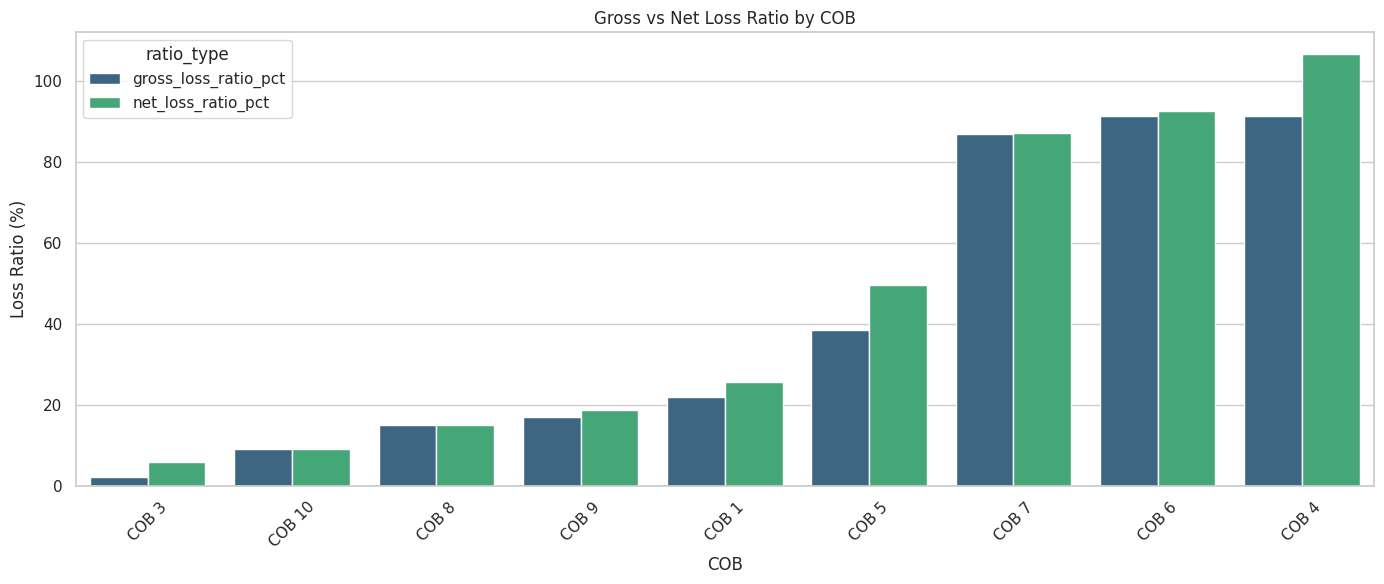

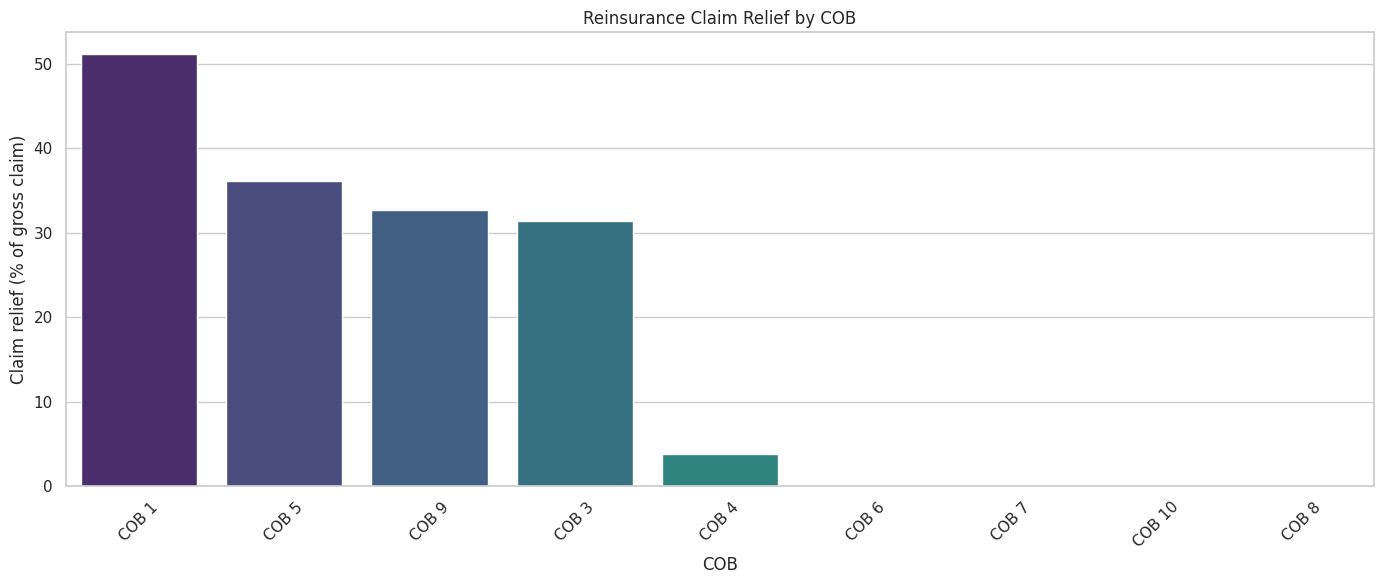

Segmen paling menguntungkan pada dimensi fokus:


,COB,policy_count,claim_policy_count,gross_loss_ratio_pct,net_loss_ratio_pct,net_underwriting_result
0,COB 3,835,36,2.23,6.03,"16,360,822,868.21"


Segmen paling merugikan pada dimensi fokus:


,COB,policy_count,claim_policy_count,gross_loss_ratio_pct,net_loss_ratio_pct,net_underwriting_result
8,COB 4,1693,208,91.27,106.55,"-91,673,129,622.13"


In [7]:
focus_summary = segment_summaries[FOCUS_SEGMENT].copy()
display(focus_summary)

chart_data = focus_summary.melt(
    id_vars=[FOCUS_SEGMENT],
    value_vars=['gross_loss_ratio_pct', 'net_loss_ratio_pct'],
    var_name='ratio_type',
    value_name='loss_ratio_pct'
)

plt.figure(figsize=(14, 6))
sns.barplot(data=chart_data, x=FOCUS_SEGMENT, y='loss_ratio_pct', hue='ratio_type', palette='viridis')
plt.title(f'Gross vs Net Loss Ratio by {FOCUS_SEGMENT}')
plt.xlabel(FOCUS_SEGMENT)
plt.ylabel('Loss Ratio (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
sns.barplot(
    data=focus_summary.sort_values('claim_relief_pct_of_gross_claim', ascending=False),
    x=FOCUS_SEGMENT, y='claim_relief_pct_of_gross_claim', palette='viridis'
)
plt.title(f'Reinsurance Claim Relief by {FOCUS_SEGMENT}')
plt.xlabel(FOCUS_SEGMENT)
plt.ylabel('Claim relief (% of gross claim)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_focus = focus_summary.nsmallest(1, 'net_loss_ratio_pct')
worst_focus = focus_summary.nlargest(1, 'net_loss_ratio_pct')

print('Segmen paling menguntungkan pada dimensi fokus:')
display(best_focus[[FOCUS_SEGMENT, 'policy_count', 'claim_policy_count', 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'net_underwriting_result']])
print('Segmen paling merugikan pada dimensi fokus:')
display(worst_focus[[FOCUS_SEGMENT, 'policy_count', 'claim_policy_count', 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'net_underwriting_result']])


,scenario,policy_count,claim_policy_count,gwp,rwp,net_premium,gross_claim,reinsurance_recovery,net_claim,gross_loss_ratio_pct,net_loss_ratio_pct,premium_ceded_pct,claim_relief_pct_of_gross_claim,gross_underwriting_result,net_underwriting_result
0,Actual portfolio,156301,8585,"2,510,719,474,050.44","546,598,216,481.78","1,964,121,257,568.66","1,238,881,565,028.47","89,128,475,259.40","1,149,753,089,769.06",49.34,58.54,21.77,7.19,"712,039,594,336.15","358,745,337,626.98"
1,Sensitivity: excluding large-claim impact,156301,8155,"2,510,719,474,050.44","546,598,216,481.78","1,964,121,257,568.66","105,343,445,648.14","5,827,565,210.57","99,515,880,437.56",4.20,5.07,21.77,5.53,"1,845,577,713,716.48","1,408,982,546,958.48"


,COB,net_lr_actual_pct,net_lr_sensitivity_ex_large_pct,delta_pct_point,net_uw_actual,net_uw_sensitivity_ex_large
8,COB 4,106.55,1.43,105.11,"-91,673,129,622.13","184,774,980,570.08"
7,COB 6,92.40,0.29,92.11,"-149,909,632,903.73","232,523,574,625.40"
6,COB 7,87.00,22.40,64.59,"-12,122,247,501.23","209,240,842,324.18"
5,COB 5,49.60,1.57,48.03,"30,315,609,202.71","66,188,357,243.41"
4,COB 1,25.73,2.49,23.24,"30,912,939,274.31","42,461,457,232.11"
3,COB 9,18.83,2.31,16.52,"370,868,350,102.74","447,994,844,429.54"
2,COB 8,15.04,0.15,14.90,"104,288,841,138.22","141,748,473,285.69"
1,COB 10,9.05,5.71,3.34,"48,541,621,544.89","50,708,951,946.64"
0,COB 3,6.03,3.28,2.76,"16,360,822,868.21","16,761,801,778.41"


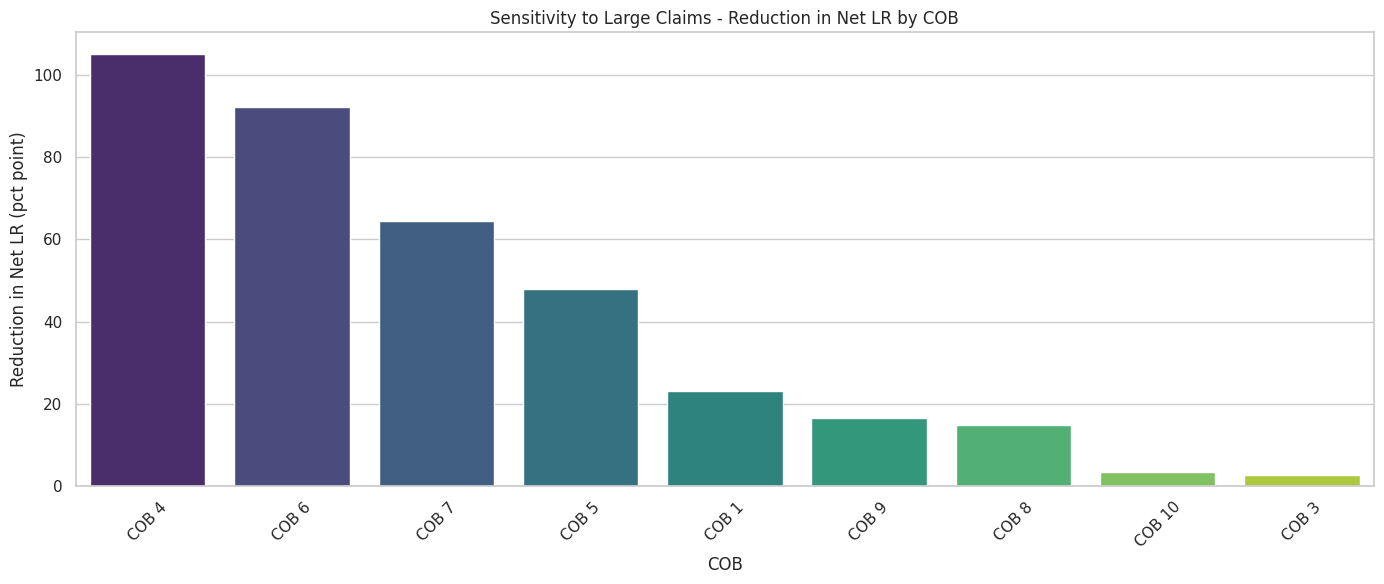

In [8]:
# Large claim analysis ini bersifat sensitivity analysis, bukan proyeksi realistis.
# Premium tetap dipertahankan, hanya impact claim besar yang di-zero-out.
df_no_large = df.copy()
df_no_large.loc[df_no_large['is_large_claim'], ['gross_claim', 'reinsurance_recovery', 'net_claim']] = 0
df_no_large['gross_underwriting_result'] = df_no_large['GWP_IDR'] - df_no_large['gross_claim'] - df_no_large['GWC_IDR']
df_no_large['net_underwriting_result'] = df_no_large['net_premium'] - df_no_large['net_claim'] - df_no_large['net_commission']
df_no_large['has_claim'] = df_no_large['gross_claim'] > 0

portfolio_compare = pd.concat([
    overall_metrics(df, 'Actual portfolio'),
    overall_metrics(df_no_large, 'Sensitivity: excluding large-claim impact')
], ignore_index=True)
display(portfolio_compare)

impact_rows = []
for seg_value in focus_summary[FOCUS_SEGMENT].tolist():
    base = df[df[FOCUS_SEGMENT] == seg_value].copy()
    adj = df_no_large[df_no_large[FOCUS_SEGMENT] == seg_value].copy()
    base_metrics = overall_metrics(base, 'base').iloc[0]
    adj_metrics = overall_metrics(adj, 'adjusted').iloc[0]
    impact_rows.append({
        FOCUS_SEGMENT: seg_value,
        'net_lr_actual_pct': base_metrics['net_loss_ratio_pct'],
        'net_lr_sensitivity_ex_large_pct': adj_metrics['net_loss_ratio_pct'],
        'delta_pct_point': base_metrics['net_loss_ratio_pct'] - adj_metrics['net_loss_ratio_pct'],
        'net_uw_actual': base_metrics['net_underwriting_result'],
        'net_uw_sensitivity_ex_large': adj_metrics['net_underwriting_result']
    })

impact_by_focus = pd.DataFrame(impact_rows).sort_values('delta_pct_point', ascending=False)
display(impact_by_focus)

plt.figure(figsize=(14, 6))
sns.barplot(data=impact_by_focus, x=FOCUS_SEGMENT, y='delta_pct_point', palette='viridis')
plt.title(f'Sensitivity to Large Claims - Reduction in Net LR by {FOCUS_SEGMENT}')
plt.xlabel(FOCUS_SEGMENT)
plt.ylabel('Reduction in Net LR (pct point)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


,uw_year,gwp,rwp,net_premium,gross_claim,reinsurance_recovery,net_claim,gross_underwriting_result,net_underwriting_result,gross_loss_ratio_pct,net_loss_ratio_pct,premium_ceded_pct,claim_relief_pct_of_gross_claim
0,2021,"1,557,352,471,342.61","198,663,691,694.63","1,358,688,779,647.98","984,489,956,173.63","50,065,141,944.37","934,424,814,229.26","130,847,213,882.00","18,878,311,841.86",63.22,68.77,12.76,5.09
1,2022,"471,373,718,715.47","174,502,558,454.08","296,871,160,261.39","112,610,571,387.11","15,290,234,926.43","97,320,336,460.67","299,510,682,552.82","173,589,203,442.83",23.89,32.78,37.02,13.58
2,2023,"481,993,283,992.36","173,431,966,333.07","308,561,317,659.29","141,781,037,467.73","23,773,098,388.59","118,007,939,079.13","281,681,697,901.32","166,277,822,342.29",29.42,38.24,35.98,16.77


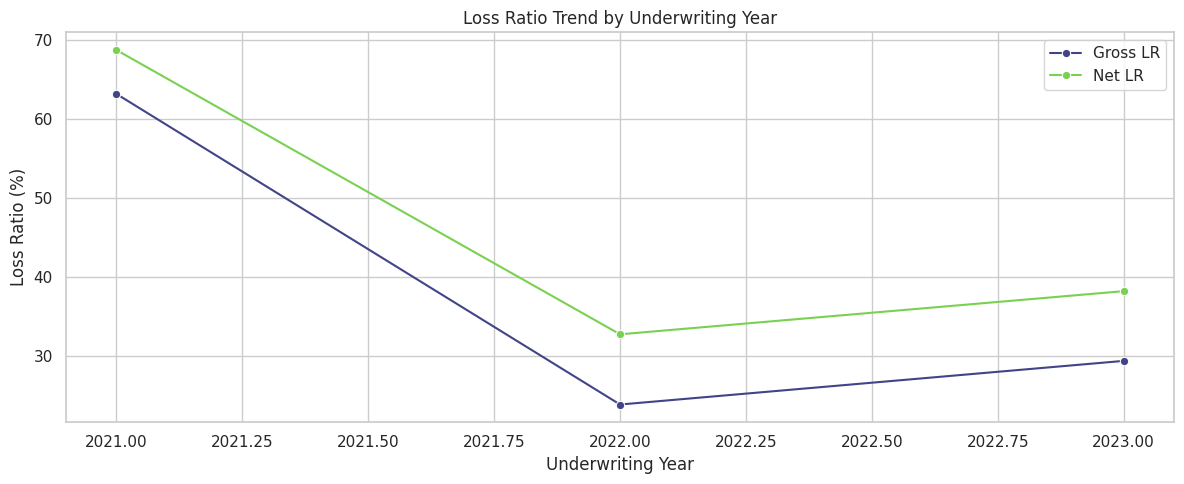

,uw_year,COB,net_premium,net_claim,net_loss_ratio_pct
0,2021,COB 10,"11,481,433,694.38","2,082,258,596.38",18.14
1,2021,COB 3,"3,937,006,957.49","286,812,024.68",7.29
2,2021,COB 4,"210,455,257,936.77","252,030,604,001.85",119.75
3,2021,COB 6,"405,911,997,232.40","368,884,899,496.30",90.88
4,2021,COB 7,"164,563,355,587.91","223,236,640,976.42",135.65
5,2021,COB 8,"246,492,726,277.02","37,549,499,255.27",15.23
6,2022,COB 10,"23,896,611,537.69","2,657,982,182.53",11.12
7,2022,COB 3,"5,068,694,321.06","420,524,090.87",8.30
8,2022,COB 4,"33,338,036,433.25","19,536,290,763.66",58.60
9,2022,COB 6,"3,832,365,945.65","218,401,437.88",5.70


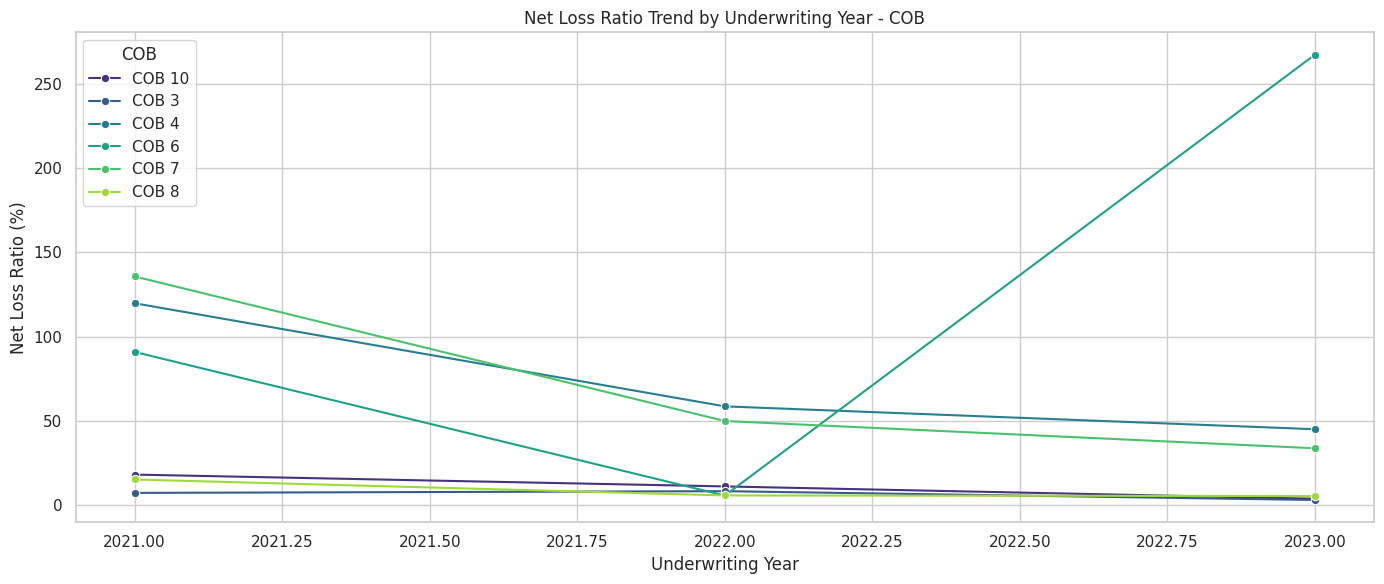

In [9]:
yearly = (
    df.groupby('uw_year', as_index=False)
    .agg(
        gwp=('GWP_IDR', 'sum'),
        rwp=('RWP_IDR', 'sum'),
        net_premium=('net_premium', 'sum'),
        gross_claim=('gross_claim', 'sum'),
        reinsurance_recovery=('reinsurance_recovery', 'sum'),
        net_claim=('net_claim', 'sum'),
        gross_underwriting_result=('gross_underwriting_result', 'sum'),
        net_underwriting_result=('net_underwriting_result', 'sum')
    )
)

yearly['gross_loss_ratio_pct'] = 100 * yearly['gross_claim'] / yearly['gwp']
yearly['net_loss_ratio_pct'] = 100 * yearly['net_claim'] / yearly['net_premium']
yearly['premium_ceded_pct'] = 100 * yearly['rwp'] / yearly['gwp']
yearly['claim_relief_pct_of_gross_claim'] = 100 * safe_ratio(yearly['reinsurance_recovery'], yearly['gross_claim'])
display(yearly)

plt.figure(figsize=(12, 5))
sns.lineplot(data=yearly, x='uw_year', y='gross_loss_ratio_pct', marker='o', label='Gross LR', color=plt.cm.viridis(0.2))
sns.lineplot(data=yearly, x='uw_year', y='net_loss_ratio_pct', marker='o', label='Net LR', color=plt.cm.viridis(0.8))
plt.title('Loss Ratio Trend by Underwriting Year')
plt.xlabel('Underwriting Year')
plt.ylabel('Loss Ratio (%)')
plt.tight_layout()
plt.show()

selected_segments = pd.concat([
    focus_summary.nsmallest(3, 'net_loss_ratio_pct')[[FOCUS_SEGMENT]],
    focus_summary.nlargest(3, 'net_loss_ratio_pct')[[FOCUS_SEGMENT]]
])[FOCUS_SEGMENT].drop_duplicates().tolist()

trend_by_segment = (
    df[df[FOCUS_SEGMENT].isin(selected_segments)]
    .groupby(['uw_year', FOCUS_SEGMENT], as_index=False)
    .agg(
        net_premium=('net_premium', 'sum'),
        net_claim=('net_claim', 'sum')
    )
)
trend_by_segment['net_loss_ratio_pct'] = 100 * trend_by_segment['net_claim'] / trend_by_segment['net_premium']
display(trend_by_segment)

plt.figure(figsize=(14, 6))
sns.lineplot(data=trend_by_segment, x='uw_year', y='net_loss_ratio_pct', hue=FOCUS_SEGMENT, marker='o', palette='viridis')
plt.title(f'Net Loss Ratio Trend by Underwriting Year - {FOCUS_SEGMENT}')
plt.xlabel('Underwriting Year')
plt.ylabel('Net Loss Ratio (%)')
plt.tight_layout()
plt.show()


In [10]:
print('INTERPRETATION GUIDE')
print('- Net Loss Ratio > 100% => segmen loss-making dari sudut pandang klaim terhadap net premium.')
print('- Net Underwriting Result < 0 => profit underwriting sederhana negatif setelah premi, klaim, dan komisi.')
print('- Reinsurance recovery tinggi => reasuransi membantu menurunkan beban claim secara nominal.')
print('- Net LR lebih tinggi dari Gross LR tidak otomatis berarti reasuransi buruk, karena net premium memang lebih kecil.')
print('- Large-claim section adalah sensitivity analysis ekstrem, bukan forecast realistis kondisi actual tanpa large claim.')
print('- Product ranking utama sudah mengecualikan outlier ekstrem; lihat tabel outlier secara terpisah.')

for col, summary in segment_summaries.items():
    best = summary.nsmallest(1, 'net_loss_ratio_pct')
    worst = summary.nlargest(1, 'net_loss_ratio_pct')
    print(f'\nDimensi: {col}')
    print('Paling menguntungkan:')
    display(best[[col, 'policy_count', 'claim_policy_count', 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'claim_relief_pct_of_gross_claim', 'net_underwriting_result', 'profitability_flag']])
    print('Paling merugikan:')
    display(worst[[col, 'policy_count', 'claim_policy_count', 'gross_loss_ratio_pct', 'net_loss_ratio_pct', 'claim_relief_pct_of_gross_claim', 'net_underwriting_result', 'profitability_flag']])

print('\nProduct outliers yang dikeluarkan dari ranking utama:')
display(product_outliers.head(TOP_N))


INTERPRETATION GUIDE
- Net Loss Ratio > 100% => segmen loss-making dari sudut pandang klaim terhadap net premium.
- Net Underwriting Result < 0 => profit underwriting sederhana negatif setelah premi, klaim, dan komisi.
- Reinsurance recovery tinggi => reasuransi membantu menurunkan beban claim secara nominal.
- Net LR lebih tinggi dari Gross LR tidak otomatis berarti reasuransi buruk, karena net premium memang lebih kecil.
- Large-claim section adalah sensitivity analysis ekstrem, bukan forecast realistis kondisi actual tanpa large claim.
- Product ranking utama sudah mengecualikan outlier ekstrem; lihat tabel outlier secara terpisah.

Dimensi: COB
Paling menguntungkan:


,COB,policy_count,claim_policy_count,gross_loss_ratio_pct,net_loss_ratio_pct,claim_relief_pct_of_gross_claim,net_underwriting_result,profitability_flag
0,COB 3,835,36,2.23,6.03,31.43,"16,360,822,868.21",Profitable/acceptable


Paling merugikan:


,COB,policy_count,claim_policy_count,gross_loss_ratio_pct,net_loss_ratio_pct,claim_relief_pct_of_gross_claim,net_underwriting_result,profitability_flag
8,COB 4,1693,208,91.27,106.55,3.82,"-91,673,129,622.13",Loss-making



Dimensi: BRANCH_
Paling menguntungkan:


...

,PRODUCT_NAME,policy_count,claim_policy_count,gross_loss_ratio_pct,net_loss_ratio_pct,claim_relief_pct_of_gross_claim,net_underwriting_result,profitability_flag
0,PRODUCT1006,1593,19,2.60,2.62,0.00,"4,738,704,749.81",Profitable/acceptable


Paling merugikan:


,PRODUCT_NAME,policy_count,claim_policy_count,gross_loss_ratio_pct,net_loss_ratio_pct,claim_relief_pct_of_gross_claim,net_underwriting_result,profitability_flag
15,PRODUCT0221,37522,6156,120.50,120.59,0.00,"-80,428,514,972.14",Loss-making



Product outliers yang dikeluarkan dari ranking utama:


,PRODUCT_NAME,policy_count,claim_policy_count,net_premium,net_claim,net_loss_ratio_pct
